# fMRI 1D to 3D Conversion

Notebook này hướng dẫn cách chuyển đổi dữ liệu fMRI từ dạng vector phẳng (15,724 voxels) sang khối 3D nhỏ gọn (Compact 3D) để phục vụ cho mô hình 3D Denoising U-Net.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import h5py
import os

# Đường dẫn các file
mapping_path = '/home/sowwn/Workspace/ws/2026/I2fMRI/data/fmri_3d_compact_mapping_subj01.npz'
fmri_path = '/home/sowwn/Workspace/ws/2026/I2fMRI/dataset/nsd/subj01/betas_all_subj01_fp32_renorm.hdf5'

# Load mapping
mapping = np.load(mapping_path)
print("Compact Shape:", mapping['compact_shape'])
print("Number of Voxels:", len(mapping['coords_compact']))

Compact Shape: [61 46 42]
Number of Voxels: 15724


## 1. Định nghĩa hàm chuyển đổi

In [2]:
class FMRI3DConverter:
    def __init__(self, mapping_path):
        m = np.load(mapping_path)
        self.compact_shape = tuple(m['compact_shape'])
        self.coords_compact = m['coords_compact']
        self.n_voxels = len(self.coords_compact)
        
        # Tạo mask 3D sẵn để dùng sau này
        self.compact_mask = np.zeros(self.compact_shape, dtype=bool)
        self.compact_mask[self.coords_compact[:, 0], 
                          self.coords_compact[:, 1], 
                          self.coords_compact[:, 2]] = True
        
    def to_3d(self, fmri_1d):
        """
        Chuyển từ [B, 15724] sang [B, 1, D, H, W]
        """
        batch_size = fmri_1d.shape[0]
        fmri_3d = np.zeros((batch_size,) + self.compact_shape, dtype=fmri_1d.dtype)
        
        # Vectorized mapping
        fmri_3d[:, self.coords_compact[:, 0], 
                  self.coords_compact[:, 1], 
                  self.coords_compact[:, 2]] = fmri_1d
        
        return fmri_3d[:, np.newaxis, ...]

    def to_1d(self, fmri_3d):
        """
        Chuyển từ [B, 1, D, H, W] ngược lại [B, 15724]
        """
        if fmri_3d.ndim == 5:
            fmri_3d = fmri_3d.squeeze(1)
            
        fmri_1d = fmri_3d[:, self.coords_compact[:, 0], 
                             self.coords_compact[:, 1], 
                             self.coords_compact[:, 2]]
        return fmri_1d

converter = FMRI3DConverter(mapping_path)

## 2. Thử nghiệm trên dữ liệu thật

In [3]:
# Load 5 mẫu đầu tiên
with h5py.File(fmri_path, 'r') as f:
    data_1d = f['betas'][:5]

print("Gốc (1D):", data_1d.shape)

# Chuyển sang 3D
data_3d = converter.to_3d(data_1d)
print("Chuyển đổi (3D):", data_3d.shape)

# Chuyển ngược lại 1D
recon_1d = converter.to_1d(data_3d)
print("Dựng lại (1D):", recon_1d.shape)

# Kiểm tra sai số
diff = np.abs(data_1d - recon_1d).max()
print(f"Sai số tối đa: {diff}")
assert diff < 1e-6, "Lỗi: Dữ liệu không khớp sau khi phục hồi!"

Gốc (1D): (5, 15724)
Chuyển đổi (3D): (5, 1, 61, 46, 42)
Dựng lại (1D): (5, 15724)
Sai số tối đa: 0.0


## 3. Trực quan hóa 3D
Chúng ta sẽ xem thử lát cắt (slice) của khối 3D.

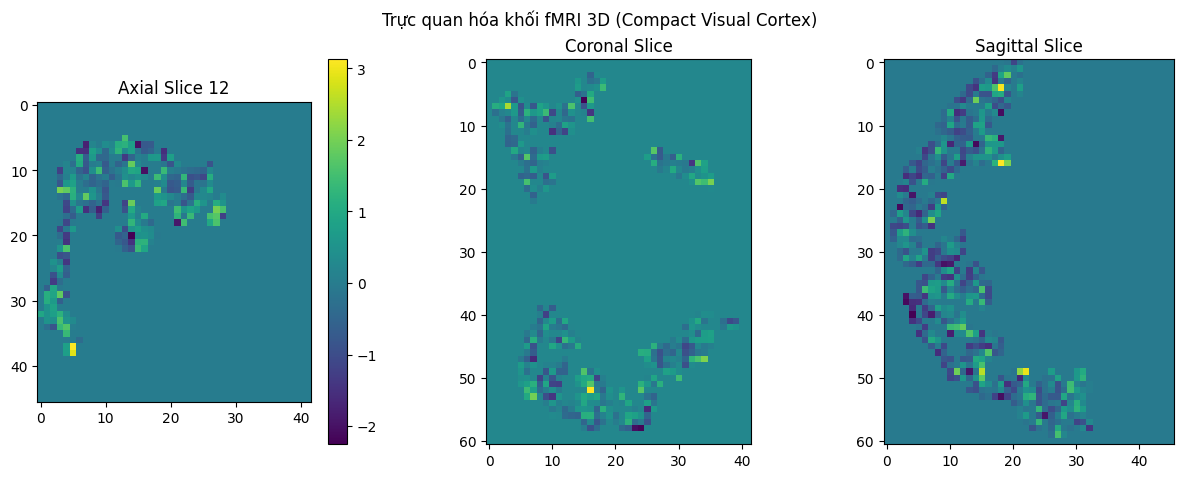

In [6]:
sample_idx = 0
volume = data_3d[sample_idx, 0]

# Tìm lát cắt có nhiều tín hiệu nhất
best_slice = np.argmax(np.sum(volume, axis=(1, 2)))

plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(volume[best_slice, :, :], cmap='viridis')
plt.title(f'Axial Slice {best_slice}')
plt.colorbar()

plt.subplot(132)
plt.imshow(volume[:, volume.shape[1]//2, :], cmap='viridis')
plt.title('Coronal Slice')

plt.subplot(133)
plt.imshow(volume[:, :, volume.shape[2]//2], cmap='viridis')
plt.title('Sagittal Slice')

plt.suptitle("Trực quan hóa khối fMRI 3D (Compact Visual Cortex)")
plt.show()

## 4. Tạo và trực quan hóa Mean 3D fMRI
Giá trị trung bình (mean) của toàn bộ tập dữ liệu thường được dùng làm 'baseline' (x_0) trong các mô hình Denoising/Diffusion.

Đang tính toán Mean fMRI (có thể mất vài giây)...
Mean 1D Shape: (15724,)
Mean 3D Shape: (61, 46, 42)


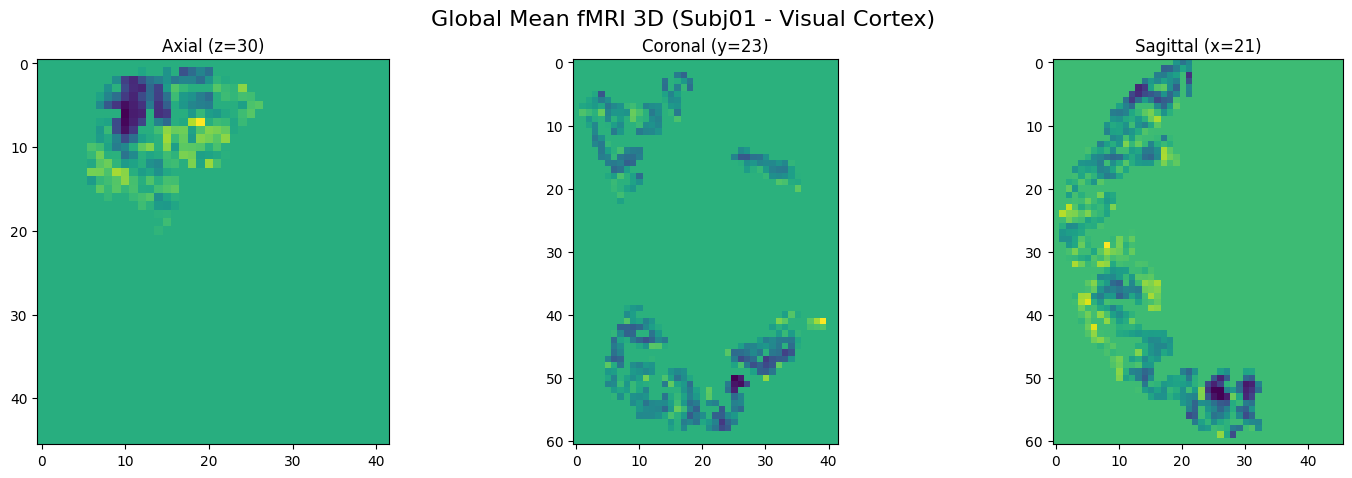

In [5]:
# 1. Tính toán Mean 1D từ toàn bộ tập dữ liệu (Subject 01)
print("Đang tính toán Mean fMRI (có thể mất vài giây)...")
with h5py.File(fmri_path, 'r') as f:
    all_fmri = f['betas'][:]
    mean_fmri_1d = np.mean(all_fmri, axis=0)

print(f"Mean 1D Shape: {mean_fmri_1d.shape}")

# 2. Chuyển đổi sang 3D
mean_3d = converter.to_3d(mean_fmri_1d[np.newaxis, ...])
mean_volume = mean_3d[0, 0]
print(f"Mean 3D Shape: {mean_volume.shape}")

# 3. Trực quan hóa các lát cắt của Mean Brain
def plot_brain_3d(volume, title="3D fMRI Volume"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Axial slice
    z_mid = volume.shape[0] // 2
    axes[0].imshow(volume[z_mid, :, :], cmap='viridis')
    axes[0].set_title(f'Axial (z={z_mid})')
    
    # Coronal slice
    y_mid = volume.shape[1] // 2
    axes[1].imshow(volume[:, y_mid, :], cmap='viridis')
    axes[1].set_title(f'Coronal (y={y_mid})')
    
    # Sagittal slice
    x_mid = volume.shape[2] // 2
    axes[2].imshow(volume[:, :, x_mid], cmap='viridis')
    axes[2].set_title(f'Sagittal (x={x_mid})')
    
    plt.suptitle(title, fontsize=16)
    plt.show()

plot_brain_3d(mean_volume, title="Global Mean fMRI 3D (Subj01 - Visual Cortex)")